In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D2 in response_OUS
data = list(OUS_D2['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D2 with response_OUS
clinical_train = pd.merge(OUS_D2, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D2['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D2 in response_MAASTRO
data = list(MAASTRO_D2['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D2 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D2, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,0.765178,0.610062,30.504395,50.002093,52.886671,58.000000,47.759816,58.864251,38067.208333,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,0.776540,0.504616,21.069386,41.753334,44.922155,44.294469,44.147480,48.723711,17870.791667,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,0.697164,0.478604,21.238275,44.375483,48.466483,45.891176,37.656341,48.969378,17426.500000,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,0.574636,0.446059,20.570459,46.115989,42.544095,47.507894,33.837849,55.226805,12463.791667,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,0.633419,0.480378,26.130155,54.394967,66.030296,56.320511,45.398238,67.089492,28300.125000,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,0.882411,0.577884,19.774388,34.218615,41.785165,40.261644,35.805028,43.520110,12822.458333,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,0.535802,0.455642,23.259099,51.046869,51.264022,51.264022,33.600595,52.440442,18368.291667,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,0.716610,0.631485,31.838169,50.417953,46.324939,56.035703,57.070132,57.671483,35384.541667,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,0.665145,0.628338,28.213278,44.901412,50.289164,50.596443,35.777088,51.478151,26180.208333,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 374)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 376)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()  
X_std = scaler.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns, index=X.index)

In [19]:
X_std

,shape_Elongation,shape_Flatness,shape_LeastAxisLength,shape_MajorAxisLength,shape_Maximum2DDiameterColumn,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,...,LBP_003_PET,LBP_012_PET,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET
0,-0.485459,0.064971,0.106464,0.059912,0.040088,0.016991,-0.128772,0.030929,0.088920,-0.225260,...,1.259511,-0.187895,-0.237601,0.332001,0.000000,-0.255811,-0.228027,0.038290,-0.362826,-0.200426
1,0.666232,-0.952446,-1.099567,-0.755402,-0.875769,-0.824341,-0.652457,-0.744926,-0.477418,-0.603339,...,3.566490,3.137073,0.913224,-1.314176,0.000000,2.591499,1.070407,1.827361,1.866886,0.869468
2,0.337179,0.444285,0.660909,0.338093,0.468616,0.259750,0.440538,0.543698,0.630069,0.754279,...,0.000000,0.082981,0.129427,0.390580,0.524263,-0.050487,-0.580607,-0.345359,-0.452526,-0.057457
3,0.695653,-0.718597,-0.979079,-0.709822,-0.930040,-0.881308,-0.331090,-0.564759,-0.457375,-0.522339,...,3.059892,2.449854,0.967575,-1.179161,0.000000,0.280373,1.104438,-0.345359,1.114908,1.522258
4,0.617917,-0.496529,-0.535096,-0.285114,-0.602328,-0.244920,-0.174518,-0.266658,-0.386906,0.069107,...,0.000000,0.190665,0.869189,-1.477904,3.028668,2.691677,1.352218,2.133915,2.946000,3.137491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,-0.105628,-0.004852,-0.358757,-0.360532,-0.402004,-0.263575,-0.567218,-0.358084,-0.246111,-0.455811,...,0.000000,-0.007844,-0.258121,0.163381,0.000000,-0.508000,0.087068,-0.345359,-0.405549,-0.231420
135,0.267171,1.278289,0.793049,0.011834,0.186224,0.312548,0.304548,0.236335,0.478786,0.257736,...,0.401955,0.179343,0.399712,-0.028726,0.000000,0.619505,-0.164891,0.144386,-0.060514,0.645662
136,0.324219,0.748713,0.215283,-0.194798,-0.504568,-0.064017,0.452283,-0.154471,0.051287,0.016210,...,0.000000,-0.577753,-0.765863,0.578039,0.000000,-0.732668,-0.221085,-0.345359,-0.504845,0.294840
137,-0.351598,-0.195069,0.112013,0.237230,0.100387,0.086725,0.028168,0.200249,0.183658,0.069765,...,0.000000,-0.253379,0.106163,-0.097845,0.000000,0.215431,0.189762,-0.008205,-0.032466,0.889136


# Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

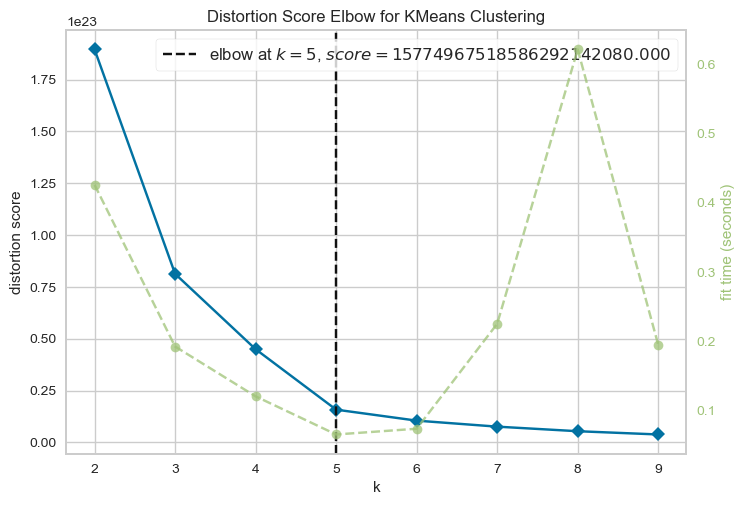

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Choose how many clusters to make 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [21]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_CT_c16
Correlation coefficient: 70.1247383577268


1
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_c04
Correlation coefficient: 5087.237820106097


2
Most correlated column: glszm_LargeAreaLowGrayLevelEmphasis_PET_b2
Correlation coefficient: 1055.19167151558


3
Most correlated column: glcm_ClusterProminence_d_1_CT_c16
Correlation coefficient: 14.377279628375122


4
Most correlated column: gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
Correlation coefficient: 46.818339041452326




In [22]:
selected_features

['glszm_LargeAreaLowGrayLevelEmphasis_CT_c16',
 'glszm_LargeAreaLowGrayLevelEmphasis_PET_c04',
 'glszm_LargeAreaLowGrayLevelEmphasis_PET_b2',
 'glcm_ClusterProminence_d_1_CT_c16',
 'gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20']

In [23]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [24]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [25]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [26]:
X_new

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterProminence_d_1_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,7442.066260,879096.343994,2.625216e+05,64.095710,0.056560
1,238.870676,26566.901706,1.242203e+05,179.749734,0.095346
2,12957.157420,647295.586841,2.397332e+06,141.966662,0.052264
3,233.632355,40145.962374,1.252457e+06,214.472104,0.027762
4,121.921768,10927.978256,1.366458e+05,610.141126,0.034148
...,...,...,...,...,...
134,1528.464999,215024.891557,4.128076e+05,39.310068,0.176183
135,41182.958565,338158.975184,3.892908e+06,96.763592,0.148848
136,3964.057173,974304.249507,1.734434e+05,201.685960,0.130961
137,5243.112516,199030.525466,1.164868e+06,95.689874,0.258550


In [27]:
X_new_std

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterProminence_d_1_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,0.233483,0.627985,-0.165378,-0.274288,-0.473236
1,-0.164858,-0.249270,-0.309221,-0.041074,-0.033964
2,0.538471,0.389462,2.054971,-0.117263,-0.521881
3,-0.165148,-0.235297,0.864223,0.028943,-0.799374
4,-0.171326,-0.265362,-0.296297,0.826802,-0.727051
...,...,...,...,...,...
134,-0.093543,-0.055346,-0.009070,-0.324268,0.881543
135,2.099375,0.071360,3.610473,-0.208414,0.571968
136,0.041147,0.725955,-0.258025,0.003160,0.369390
137,0.111879,-0.071804,0.773124,-0.210579,1.814381


In [28]:
MAASTRO_new

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterProminence_d_1_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,9404.025346,1.125054e+06,3.686456e+05,156.527507,0.203608
1,16468.863361,1.948450e+06,2.114589e+06,447.924077,0.077923
2,3829.811759,1.403912e+06,4.579214e+05,784.580957,0.119332
3,2212.056593,4.555744e+05,9.121242e+05,1564.507789,1.487269
4,20185.616389,8.660429e+05,3.260921e+06,26.806072,0.129126
...,...,...,...,...,...
94,18006.593217,9.500595e+05,5.034748e+04,80.816281,0.097901
95,1303.136099,3.718008e+06,8.736992e+05,5250.361286,0.135426
96,8928.353080,2.726200e+06,7.999319e+06,238.811635,0.083343
97,13835.684015,2.138315e+06,6.943470e+05,56.598117,0.071296


In [29]:
MAASTRO_new_std

,glszm_LargeAreaLowGrayLevelEmphasis_CT_c16,glszm_LargeAreaLowGrayLevelEmphasis_PET_c04,glszm_LargeAreaLowGrayLevelEmphasis_PET_b2,glcm_ClusterProminence_d_1_CT_c16,gldm_LargeDependenceLowGrayLevelEmphasis_d_1_CT_b20
0,0.341981,0.881077,-0.055002,-0.087901,1.192147
1,0.732670,1.728353,1.760899,0.499694,-0.231290
2,0.033723,1.168022,0.037851,1.178557,0.237686
3,-0.055740,0.192180,0.510253,2.751265,15.730108
4,0.938209,0.614553,2.953163,-0.349482,0.348610
...,...,...,...,...,...
94,0.817708,0.701007,-0.386054,-0.240572,-0.005024
95,-0.106004,3.549233,0.470289,10.183719,0.419960
96,0.315676,2.528660,7.881422,0.078023,-0.169908
97,0.587054,1.923725,0.283750,-0.289407,-0.306341


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [30]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:31:08,035] A new study created in memory with name: no-name-6e4f97da-6375-4d42-b3c8-d49ee7c8b56f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5099601593625498
Fold 2 C-index: 0.686046511627907
Fold 3 C-index: 0.7276595744680852
Fold 4 C-index: 0.45627376425855515


[I 2024-04-14 16:31:08,873] A new study created in memory with name: no-name-39601523-a2c5-4f49-889c-370049fce824


Fold 5 C-index: 0.3948497854077253
[I 2024-04-14 16:31:08,862] Trial 0 finished with value: 0.5549579590249645 and parameters: {}. Best is trial 0 with value: 0.5549579590249645.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5549579590249645], datetime_start=datetime.datetime(2024, 4, 14, 16, 31, 8, 225784), datetime_complete=datetime.datetime(2024, 4, 14, 16, 31, 8, 861832), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5549579590249645


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2435372644495335
Fold 2 IBS: 0.21705145299023965
Fold 3 IBS: 0.2105063979006956
Fold 4 IBS: 0.25749691497763616
Fold 5 IBS: 0.23489159348985172
[I 2024-04-14 16:31:09,476] Trial 0 finished with value: 0.23269672476159134 and parameters: {}. Best is trial 0 with value: 0.23269672476159134.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23269672476159134], datetime_start=datetime.datetime(2024, 4, 14, 16, 31, 8, 927529), datetime_complete=datetime.datetime(2024, 4, 14, 16, 31, 9, 468458), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23269672476159134


In [31]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [32]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.555
train_ibs:  0.233


#### Test

In [33]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [34]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.525
IBS score: 0.237


In [35]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [36]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [37]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:31:09,944] A new study created in memory with name: no-name-db0dc6e1-fed2-41df-8ed6-e4c3be55eb82


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-14 16:31:10,276] A new study created in memory with name: no-name-d542f091-fdd2-4038-b250-091b21b9e4c1


Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6608527131782945
Fold 3 C-index: 0.7085106382978723
Fold 4 C-index: 0.5456273764258555
Fold 5 C-index: 0.5236051502145923
[I 2024-04-14 16:31:10,254] Trial 0 finished with value: 0.5721813270177452 and parameters: {}. Best is trial 0 with value: 0.5721813270177452.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5721813270177452], datetime_start=datetime.datetime(2024, 4, 14, 16, 31, 9, 993161), datetime_complete=datetime.datetime(2024, 4, 14, 16, 31, 10, 254100), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5721813270177452


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724711869367466
Fold 2 IBS: 0.23203987663984238
Fold 3 IBS: 0.2289818647147173
Fold 4 IBS: 0.24197479107544392
Fold 5 IBS: 0.22939559003281138
[I 2024-04-14 16:31:10,757] Trial 0 finished with value: 0.23592784823129792 and parameters: {}. Best is trial 0 with value: 0.23592784823129792.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784823129792], datetime_start=datetime.datetime(2024, 4, 14, 16, 31, 10, 320020), datetime_complete=datetime.datetime(2024, 4, 14, 16, 31, 10, 757460), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784823129792


In [38]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [39]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.572
train_ibs:  0.236


#### Test

In [40]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [41]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.559


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [42]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [43]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:31:11,027] A new study created in memory with name: no-name-1ebd2e6e-4567-4344-9b00-34e095407a67


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157


[I 2024-04-14 16:31:11,291] A new study created in memory with name: no-name-a6a0733c-d6c3-4f92-9fa6-ff7bfea5eacd


Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:11,275] Trial 0 finished with value: 0.5738322950513342 and parameters: {}. Best is trial 0 with value: 0.5738322950513342.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5738322950513342], datetime_start=datetime.datetime(2024, 4, 14, 16, 31, 11, 66099), datetime_complete=datetime.datetime(2024, 4, 14, 16, 31, 11, 275203), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5738322950513342


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2475597546840513
Fold 2 IBS: 0.2319284672546224
Fold 3 IBS: 0.22812179385654624
Fold 4 IBS: 0.24225811304237807
Fold 5 IBS: 0.22931739699661338
[I 2024-04-14 16:31:11,605] Trial 0 finished with value: 0.23583710516684228 and parameters: {}. Best is trial 0 with value: 0.23583710516684228.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23583710516684228], datetime_start=datetime.datetime(2024, 4, 14, 16, 31, 11, 332756), datetime_complete=datetime.datetime(2024, 4, 14, 16, 31, 11, 604903), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23583710516684228


In [44]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [45]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.574
train_ibs:  0.236


#### Test

In [46]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [47]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.229


In [48]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [49]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:31:11,835] A new study created in memory with name: no-name-97f8c228-7b73-4ced-b6d2-a5a1014ef92e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:12,070] Trial 0 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5738322950513342.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:12,314] Trial 1 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.5738322950513342.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:12,490] Trial 2 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.2269287684188466

Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:17,128] Trial 24 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.5738322950513342.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:17,358] Trial 25 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.5738322950513342.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:17,623] Trial 26 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.3312072877416

Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:22,515] Trial 48 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.5738322950513342.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:22,718] Trial 49 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.5738322950513342.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.532319391634981
Fold 5 C-index: 0.48068669527896996
[I 2024-04-14 16:31:22,920] Trial 50 finished with value: 0.5738322950513342 and parameters: {'l1_ratio': 0.5027665121167861}. Best is trial 0 with value: 0.5

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.24755958760346264
Fold 2 IBS: 0.23192851633610806
Fold 3 IBS: 0.22813255050600506
Fold 4 IBS: 0.2422579788616089
Fold 5 IBS: 0.22931745839964415
[I 2024-04-14 16:31:34,511] Trial 0 finished with value: 0.23583921834136579 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.23583921834136579.
Fold 1 IBS: 0.24755880017840598
Fold 2 IBS: 0.23192874780402192
Fold 3 IBS: 0.2281795455377153
Fold 4 IBS: 0.24225734635274424
Fold 5 IBS: 0.22931774748923892
[I 2024-04-14 16:31:34,709] Trial 1 finished with value: 0.2358484374724253 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.23583921834136579.
Fold 1 IBS: 0.2475584518990552
Fold 2 IBS: 0.23192885026387583
Fold 3 IBS: 0.22819859117492808
Fold 4 IBS: 0.24225706652157003
Fold 5 IBS: 0.22931787519940183
[I 2024-04-14 16:31:34,969] Trial 2 finished with value: 0.2358521670117662 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.23583921834136

Fold 4 IBS: 0.24225808280790104
Fold 5 IBS: 0.2293174108346429
[I 2024-04-14 16:31:42,688] Trial 25 finished with value: 0.23583758653500544 and parameters: {'l1_ratio': 0.9106143729430608}. Best is trial 11 with value: 0.2358371188417047.
Fold 1 IBS: 0.24755962115403868
Fold 2 IBS: 0.23192850647939173
Fold 3 IBS: 0.2281304142131246
Fold 4 IBS: 0.242258005806552
Fold 5 IBS: 0.2293174460713714
[I 2024-04-14 16:31:43,102] Trial 26 finished with value: 0.2358387987448957 and parameters: {'l1_ratio': 0.7417169602645222}. Best is trial 11 with value: 0.2358371188417047.
Fold 1 IBS: 0.24755954776141212
Fold 2 IBS: 0.2319285280417777
Fold 3 IBS: 0.22813507222624915
Fold 4 IBS: 0.24225794686336652
Fold 5 IBS: 0.22931747303859967
[I 2024-04-14 16:31:43,710] Trial 27 finished with value: 0.23583971358628103 and parameters: {'l1_ratio': 0.6494728799686162}. Best is trial 11 with value: 0.2358371188417047.
Fold 1 IBS: 0.24755968194202913
Fold 2 IBS: 0.23192848862186116
Fold 3 IBS: 0.22812651348412

Fold 3 IBS: 0.22812523640806623
Fold 4 IBS: 0.24225807050206635
Fold 5 IBS: 0.2293174164665217
[I 2024-04-14 16:31:53,284] Trial 50 finished with value: 0.23583778158060165 and parameters: {'l1_ratio': 0.8786447363305766}. Best is trial 40 with value: 0.23583710621283513.
Fold 1 IBS: 0.2475597342897883
Fold 2 IBS: 0.23192847324501292
Fold 3 IBS: 0.2281231228260528
Fold 4 IBS: 0.24225809666448592
Fold 5 IBS: 0.22931740449278343
[I 2024-04-14 16:31:53,582] Trial 51 finished with value: 0.23583736630362467 and parameters: {'l1_ratio': 0.9495136153828908}. Best is trial 40 with value: 0.23583710621283513.
Fold 1 IBS: 0.24755973687897778
Fold 2 IBS: 0.23192847248448295
Fold 3 IBS: 0.22812295435415192
Fold 4 IBS: 0.2422580987437783
Fold 5 IBS: 0.229317403541112
[I 2024-04-14 16:31:53,903] Trial 52 finished with value: 0.2358373332005006 and parameters: {'l1_ratio': 0.9556391205035538}. Best is trial 40 with value: 0.23583710621283513.
Fold 1 IBS: 0.24755975061435623
Fold 2 IBS: 0.23192846844

Fold 1 IBS: 0.2475597227880232
Fold 2 IBS: 0.23192847662349264
Fold 3 IBS: 0.228123870340865
Fold 4 IBS: 0.2422580874277699
Fold 5 IBS: 0.22931740872026005
[I 2024-04-14 16:32:02,055] Trial 75 finished with value: 0.23583751318008214 and parameters: {'l1_ratio': 0.9232248440809541}. Best is trial 40 with value: 0.23583710621283513.
Fold 1 IBS: 0.24755974175451345
Fold 2 IBS: 0.23192847105238537
Fold 3 IBS: 0.2281226369186482
Fold 4 IBS: 0.2422581026591531
Fold 5 IBS: 0.22931740174906667
[I 2024-04-14 16:32:02,378] Trial 76 finished with value: 0.23583727082675338 and parameters: {'l1_ratio': 0.9673906281038791}. Best is trial 40 with value: 0.23583710621283513.
Fold 1 IBS: 0.2475597113083937
Fold 2 IBS: 0.23192847999552454
Fold 3 IBS: 0.2281246149953512
Fold 4 IBS: 0.2422580782087828
Fold 5 IBS: 0.2293174129394978
[I 2024-04-14 16:32:02,653] Trial 77 finished with value: 0.23583765948951002 and parameters: {'l1_ratio': 0.8983978427418612}. Best is trial 40 with value: 0.235837106212835

In [50]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [51]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.574
train_ibs:  0.236


#### Test

In [52]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [53]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.562


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.9997874437591321)

test_ibs:  0.229


In [54]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [55]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:32:09,088] A new study created in memory with name: no-name-45b4b569-e16d-4f39-a81c-d949b86a4548


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4262948207171315
Fold 2 C-index: 0.6589147286821705
Fold 3 C-index: 0.41702127659574467
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.5128755364806867
[I 2024-04-14 16:32:16,171] Trial 0 finished with value: 0.5003596755369717 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5003596755369717.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.4723404255319149
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.48497854077253216
[I 2024-04-14 16:32:21,485] Trial 1 finished with value: 0.506180145231496 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 5 C-index: 0.6072961373390557
[I 2024-04-14 16:33:19,794] Trial 15 finished with value: 0.6257431842868864 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 7, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 79, 'oob_score': True, 'max_samples': 0.817309431417591, 'max_features': None, 'min_weight_fraction_leaf': 0.20663398741831335, 'warm_start': True}. Best is trial 14 with value: 0.6309193274753035.
Fold 1 C-index: 0.4123505976095618
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.7468085106382979
Fold 4 C-index: 0.591254752851711
Fold 5 C-index: 0.5815450643776824
[I 2024-04-14 16:33:20,236] Trial 16 finished with value: 0.6051514750179312 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 5, 'oob_score': True, 'max_samples': 0.8031281433915335, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3792168673484642, 'warm_start': True}. Best is trial 14 with value: 0.6309193274753035.
Fol

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.7364341085271318
Fold 3 C-index: 0.7531914893617021
Fold 4 C-index: 0.6083650190114068
Fold 5 C-index: 0.5965665236051502
[I 2024-04-14 16:33:39,570] Trial 30 finished with value: 0.6273576432405203 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 6, 'min_samples_leaf': 15, 'max_depth': 8, 'n_estimators': 79, 'oob_score': True, 'max_samples': 0.9563478390311455, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.3843088343404539, 'warm_start': True}. Best is trial 27 with value: 0.6500046153292012.
Fold 1 C-index: 0.4262948207171315
Fold 2 C-index: 0.7441860465116279
Fold 3 C-index: 0.7595744680851064
Fold 4 C-index: 0.6197718631178707
Fold 5 C-index: 0.6373390557939914
[I 2024-04-14 16:33:40,771] Trial 31 finished with value: 0.6374332508451456 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 3, 'min_samples_leaf': 15, 'max_depth': 2, 'n_estimators': 96, 'oob_score': True, 'max_samples': 0.7303758527159789, 

...

Fold 1 IBS: 0.24689606005072265
Fold 2 IBS: 0.2320817268872792
Fold 3 IBS: 0.22955403065487698
Fold 4 IBS: 0.2414656655771319
Fold 5 IBS: 0.2295511625496166
[I 2024-04-14 16:38:20,860] Trial 32 finished with value: 0.23590972914392547 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 10, 'min_samples_leaf': 2, 'max_depth': 16, 'n_estimators': 114, 'oob_score': True, 'max_samples': 0.14130636587960554, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1646530417162256}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.26027437211439963
Fold 2 IBS: 0.21790110242645794
Fold 3 IBS: 0.21727473174370607
Fold 4 IBS: 0.2531992897476726
Fold 5 IBS: 0.2420486288431121
[I 2024-04-14 16:38:24,884] Trial 33 finished with value: 0.23813962497506966 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 5, 'max_depth': 19, 'n_estimators': 184, 'oob_score': True, 'max_samples': 0.23399586553883964, 'max_features': 'sqrt', 'min_weight_fraction_le

Fold 1 IBS: 0.2467712700187535
Fold 2 IBS: 0.23217146811030506
Fold 3 IBS: 0.2302110778004708
Fold 4 IBS: 0.2409807955042547
Fold 5 IBS: 0.22976904677986384
[I 2024-04-14 16:39:26,651] Trial 48 finished with value: 0.2359807316427296 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 4, 'min_samples_leaf': 6, 'max_depth': 4, 'n_estimators': 252, 'oob_score': True, 'max_samples': 0.12315071250458248, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.38945674624514565}. Best is trial 20 with value: 0.23578139427431283.
Fold 1 IBS: 0.24667791610043613
Fold 2 IBS: 0.2321343511997474
Fold 3 IBS: 0.2293412353905116
Fold 4 IBS: 0.2415180056034429
Fold 5 IBS: 0.2302847108814804
[I 2024-04-14 16:39:29,619] Trial 49 finished with value: 0.23599124383512365 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 6, 'min_samples_leaf': 8, 'max_depth': 13, 'n_estimators': 168, 'oob_score': True, 'max_samples': 0.5690354368000963, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0

Fold 1 IBS: 0.24601444252731122
Fold 2 IBS: 0.23211762894154078
Fold 3 IBS: 0.22950667663998886
Fold 4 IBS: 0.24108006525844958
Fold 5 IBS: 0.23012686668076462
[I 2024-04-14 16:40:12,869] Trial 64 finished with value: 0.23576913600961102 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 152, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.1804782312702447}. Best is trial 61 with value: 0.23570613207270097.
Fold 1 IBS: 0.24645984433665466
Fold 2 IBS: 0.2321702232721768
Fold 3 IBS: 0.22962462711115939
Fold 4 IBS: 0.24103051144834467
Fold 5 IBS: 0.23005605527880266
[I 2024-04-14 16:40:16,112] Trial 65 finished with value: 0.23586825228942762 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 203, 'oob_score': True, 'max_samples': 0.17249999183105907, 'max_features': 'log2', 'min_weight_fraction_l

Fold 1 IBS: 0.24605271826694033
Fold 2 IBS: 0.23209377876548373
Fold 3 IBS: 0.2295391749388275
Fold 4 IBS: 0.24120963910632234
Fold 5 IBS: 0.23016534628589677
[I 2024-04-14 16:40:53,950] Trial 80 finished with value: 0.23581213147269411 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 20, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.2000578322214417, 'max_features': None, 'min_weight_fraction_leaf': 0.15449622499933904}. Best is trial 61 with value: 0.23570613207270097.
Fold 1 IBS: 0.24625507890134085
Fold 2 IBS: 0.2321469517921598
Fold 3 IBS: 0.22938209291229614
Fold 4 IBS: 0.24125454363916835
Fold 5 IBS: 0.22996759956807314
[I 2024-04-14 16:40:56,643] Trial 81 finished with value: 0.23580125336260765 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 7, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 145, 'oob_score': True, 'max_samples': 0.1715932679909934, 'max_features': 'sqrt', 'min_weight_fraction_leaf'

Fold 1 IBS: 0.24642535466859034
Fold 2 IBS: 0.23212276906200424
Fold 3 IBS: 0.22973888319664737
Fold 4 IBS: 0.24120581316000955
Fold 5 IBS: 0.22975387068743944
[I 2024-04-14 16:41:43,651] Trial 96 finished with value: 0.2358493381549382 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 5, 'min_samples_leaf': 5, 'max_depth': 19, 'n_estimators': 200, 'oob_score': False, 'max_samples': 0.15576144537636402, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.22430236940651693}. Best is trial 89 with value: 0.2356714317489327.
Fold 1 IBS: 0.24648548995748895
Fold 2 IBS: 0.2320862709066876
Fold 3 IBS: 0.22986865314271424
Fold 4 IBS: 0.24130803289195266
Fold 5 IBS: 0.2295994732847304
[I 2024-04-14 16:41:45,841] Trial 97 finished with value: 0.23586958403671474 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 11, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 129, 'oob_score': False, 'max_samples': 0.24863784330077493, 'max_features': 'sqrt', 'min_weight_fraction_

In [56]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [57]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.799
train_ibs:  0.236


#### Test

In [58]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [59]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=17, max_features=None, max_leaf_nodes=20,
                     max_samples=0.6510347277537242, min_samples_leaf=1,
                     min_samples_split=7,
                     min_weight_fraction_leaf=0.029762038381213243,
                     n_estimators=90, random_state=123, warm_start=True)

test_cindex:  0.593


RandomSurvivalForest(max_depth=19, max_leaf_nodes=7,
                     max_samples=0.412156354381498, min_samples_leaf=4,
                     min_samples_split=8,
                     min_weight_fraction_leaf=0.2060258475612423,
                     n_estimators=164, random_state=123)

test_ibs:  0.229


In [60]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [61]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 16:41:53,088] A new study created in memory with name: no-name-021c2926-db24-4563-aa87-8a6ea0ce1269


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4900398406374502
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.5475285171102662
Fold 5 C-index: 0.5879828326180258
[I 2024-04-14 16:41:54,583] Trial 0 finished with value: 0.6266672230640771 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6266672230640771.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:41:58,045] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.4402390438247012
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.7808510638297872
Fold 4 C-index: 0.5931558935361216
Fold 5 C-index: 0.5107296137339056
[I 2024-04-14 16:42:42,295] Trial 16 finished with value: 0.6068555881011821 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.6312792519878313.
Fold 1 C-index: 0.5079681274900398
Fold 2 C-index: 0.6375968992248062
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.5472103004291845
[I 2024-04-14 16:42:43,405] Trial 17 finished with value: 0.6067000375184428 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.4701195219123506
Fold 2 C-index: 0.7267441860465116
Fold 3 C-index: 0.7638297872340426
Fold 4 C-index: 0.5855513307984791
Fold 5 C-index: 0.5643776824034334
[I 2024-04-14 16:43:03,198] Trial 31 finished with value: 0.6221245016789634 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 13, 'max_depth': 5, 'n_estimators': 216, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.9412646507830068, 'min_weight_fraction_leaf': 0.27441926571590103}. Best is trial 28 with value: 0.6334112443091247.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7468085106382979
Fold 4 C-index: 0.6197718631178707
Fold 5 C-index: 0.5858369098712446
[I 2024-04-14 16:43:04,171] Trial 32 finished with value: 0.6215653307796536 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 15, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 289, 'oob_score': False, 'warm_start': True, 'max_feat

...

Fold 1 IBS: 0.2462104079027938
Fold 2 IBS: 0.2322065073003061
Fold 3 IBS: 0.22901000197974028
Fold 4 IBS: 0.241107441875448
Fold 5 IBS: 0.23036813805681372
[I 2024-04-14 16:48:29,285] Trial 30 finished with value: 0.23578049942302037 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 13, 'min_samples_leaf': 16, 'max_depth': 12, 'n_estimators': 87, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.5897285086805036, 'min_weight_fraction_leaf': 0.2708156863133528}. Best is trial 27 with value: 0.23516989861682233.
Fold 1 IBS: 0.2464901896575984
Fold 2 IBS: 0.23131468955277848
Fold 3 IBS: 0.22686552143987454
Fold 4 IBS: 0.24114904338887802
Fold 5 IBS: 0.230655754170387
[I 2024-04-14 16:48:32,162] Trial 31 finished with value: 0.23529503964190326 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 18, 'n_estimators': 161, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.738025

Fold 2 IBS: 0.23274632967564443
Fold 3 IBS: 0.22876536604485792
Fold 4 IBS: 0.24478267560384429
Fold 5 IBS: 0.22908541533217502
[I 2024-04-14 16:49:20,057] Trial 45 finished with value: 0.2364007199912909 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 12, 'min_samples_leaf': 17, 'max_depth': 6, 'n_estimators': 5, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.6581847740846413, 'min_weight_fraction_leaf': 0.18934842462242518}. Best is trial 27 with value: 0.23516989861682233.
Fold 1 IBS: 0.24675719970048013
Fold 2 IBS: 0.23178258060431517
Fold 3 IBS: 0.22812379460165869
Fold 4 IBS: 0.2410393968705533
Fold 5 IBS: 0.23047514595271953
[I 2024-04-14 16:49:23,927] Trial 46 finished with value: 0.23563562354594536 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 16, 'max_depth': 5, 'n_estimators': 240, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.3992697850523245, 'min_weight_

Fold 1 IBS: 0.2468701166796712
Fold 2 IBS: 0.2321207478077909
Fold 3 IBS: 0.22978306725680578
Fold 4 IBS: 0.24119695579581302
Fold 5 IBS: 0.22980259481046902
[I 2024-04-14 16:50:01,207] Trial 60 finished with value: 0.23595469647010997 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 3, 'min_samples_leaf': 10, 'max_depth': 14, 'n_estimators': 102, 'oob_score': False, 'warm_start': False, 'max_features': None, 'max_samples': 0.3272030289187819, 'min_weight_fraction_leaf': 0.2583710069782479}. Best is trial 27 with value: 0.23516989861682233.
Fold 1 IBS: 0.24639095596533836
Fold 2 IBS: 0.23178215636736896
Fold 3 IBS: 0.2271891370783781
Fold 4 IBS: 0.24163616297086896
Fold 5 IBS: 0.23045832361160348
[I 2024-04-14 16:50:03,774] Trial 61 finished with value: 0.2354913471987116 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 9, 'min_samples_leaf': 12, 'max_depth': 13, 'n_estimators': 115, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.2466426059930104
Fold 2 IBS: 0.23118262100649872
Fold 3 IBS: 0.22701708960409742
Fold 4 IBS: 0.2416168133894128
Fold 5 IBS: 0.23054450268284063
[I 2024-04-14 16:50:38,909] Trial 75 finished with value: 0.235400726535172 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 118, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.6392784099593629, 'min_weight_fraction_leaf': 0.17789838804010016}. Best is trial 62 with value: 0.23511467372394818.
Fold 1 IBS: 0.24627225897122051
Fold 2 IBS: 0.2297643330411657
Fold 3 IBS: 0.22803697914387694
Fold 4 IBS: 0.24155689450620693
Fold 5 IBS: 0.23167858142516964
[I 2024-04-14 16:50:42,114] Trial 76 finished with value: 0.23546180941752795 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 14, 'min_samples_leaf': 11, 'max_depth': 6, 'n_estimators': 168, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0

Fold 1 IBS: 0.2461578743445445
Fold 2 IBS: 0.2314646289744762
Fold 3 IBS: 0.22762084951240635
Fold 4 IBS: 0.241687541980107
Fold 5 IBS: 0.23065018772595036
[I 2024-04-14 16:51:21,958] Trial 90 finished with value: 0.23551621650749688 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 5, 'n_estimators': 84, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.5979457194757343, 'min_weight_fraction_leaf': 0.18818359713709218}. Best is trial 86 with value: 0.23511121683150032.
Fold 1 IBS: 0.24663078736181385
Fold 2 IBS: 0.23145261193797287
Fold 3 IBS: 0.22635366598746334
Fold 4 IBS: 0.24104204543150273
Fold 5 IBS: 0.23079706245000156
[I 2024-04-14 16:51:24,526] Trial 91 finished with value: 0.23525523463375086 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 18, 'min_samples_leaf': 13, 'max_depth': 11, 'n_estimators': 133, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0

In [62]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [63]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.699
train_ibs:  0.235


#### Test

In [64]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [65]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=11, max_features=None, max_leaf_nodes=18,
                   max_samples=0.7096062678481252, min_samples_leaf=1,
                   min_samples_split=17,
                   min_weight_fraction_leaf=0.01585304896780834,
                   n_estimators=459, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.595


ExtraSurvivalTrees(max_depth=9, max_features='auto', max_leaf_nodes=20,
                   max_samples=0.5076350296058434, min_samples_leaf=12,
                   min_samples_split=17,
                   min_weight_fraction_leaf=0.2009394432096618,
                   n_estimators=139, oob_score=True, random_state=123)

IBS: 0.229


In [66]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [67]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 16:51:45,483] A new study created in memory with name: no-name-9c5b81f4-c110-4594-a1a4-0f2f3870c331


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:52:11,754] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:52:24,411] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:56:42,945] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 16:57:16,547] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 17:01:38,341] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 17:01:43,771] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.46231

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:35:45,696] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:35:48,464] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:37:48,112] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-14 17:38:03,125] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:39:29,814] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:39:42,697] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:41:08,159] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:41:30,688] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:43:45,256] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-14 17:43:46,062] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [68]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [69]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [70]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [71]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [72]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [73]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 17:45:43,376] A new study created in memory with name: no-name-430e5388-a327-429d-a332-d2394b4e6dd7


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.467680608365019
Fold 5 C-index: 0.4721030042918455
[I 2024-04-14 17:45:44,198] Trial 0 finished with value: 0.586713849721113 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.586713849721113.
Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.4592274678111588
[I 2024-04-14 17:45:52,093] Trial 1 finished with value: 0.5829065724781124 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.586713849721113.
Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.6976744186046512
Fold 3 C-index: 0.8042553191489362
Fold 

Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.47639484978540775
[I 2024-04-14 17:47:09,705] Trial 19 finished with value: 0.591309021904901 and parameters: {'subsample': 0.6208056996785021, 'dropout_rate': 0.22272673907598134, 'n_estimators': 234, 'learning_rate': 0.06573972927454239}. Best is trial 14 with value: 0.5968869815558603.
Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.7872340425531915
Fold 4 C-index: 0.43346007604562736
Fold 5 C-index: 0.4592274678111588
[I 2024-04-14 17:47:10,513] Trial 20 finished with value: 0.5823137283200139 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.5558690358940764, 'n_estimators': 65, 'learning_rate': 0.07806735824908756}. Best is trial 14 with value: 0.5968869815558603.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.8127659574468085
Fo

Fold 5 C-index: 0.4592274678111588
[I 2024-04-14 17:48:04,357] Trial 37 finished with value: 0.5855208964741263 and parameters: {'subsample': 0.7465974928938772, 'dropout_rate': 0.8374055765137145, 'n_estimators': 282, 'learning_rate': 0.03895535545960089}. Best is trial 14 with value: 0.5968869815558603.
Fold 1 C-index: 0.549800796812749
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.8127659574468085
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.4721030042918455
[I 2024-04-14 17:48:08,592] Trial 38 finished with value: 0.5977088507582365 and parameters: {'subsample': 0.5452095206778702, 'dropout_rate': 0.9152759558226438, 'n_estimators': 409, 'learning_rate': 0.026260564413239186}. Best is trial 38 with value: 0.5977088507582365.
Fold 1 C-index: 0.49800796812749004
Fold 2 C-index: 0.7015503875968992
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.467680608365019
Fold 5 C-index: 0.4892703862660944
[I 2024-04-14 17:48:12,407] Trial 39 finished with value: 0.59215293390

...

Fold 2 IBS: 0.2675828133408081
Fold 3 IBS: 0.17088495144573837
Fold 4 IBS: 0.3467895423872016
Fold 5 IBS: 0.3062921972854083
[I 2024-04-14 17:54:30,798] Trial 19 finished with value: 0.28653661827986826 and parameters: {'subsample': 0.16667191735421055, 'dropout_rate': 0.994814822896155, 'n_estimators': 341, 'learning_rate': 0.08253138086495834}. Best is trial 13 with value: 0.23157807717789697.
Fold 1 IBS: 0.2512395394754341
Fold 2 IBS: 0.22205237584360837
Fold 3 IBS: 0.21320833288416247
Fold 4 IBS: 0.250865735320634
Fold 5 IBS: 0.2297985165225858
[I 2024-04-14 17:54:31,383] Trial 20 finished with value: 0.23343290000928496 and parameters: {'subsample': 0.34436144234326155, 'dropout_rate': 0.6443932854579865, 'n_estimators': 68, 'learning_rate': 0.03973446561107324}. Best is trial 13 with value: 0.23157807717789697.
Fold 1 IBS: 0.2502962864175848
Fold 2 IBS: 0.22276118761617555
Fold 3 IBS: 0.2144529950414842
Fold 4 IBS: 0.2501257032140603
Fold 5 IBS: 0.2297031212680998
[I 2024-04-14 1

Fold 2 IBS: 0.22028059177061962
Fold 3 IBS: 0.21440324817498366
Fold 4 IBS: 0.2558481396816813
Fold 5 IBS: 0.2297083350692629
[I 2024-04-14 17:54:56,074] Trial 38 finished with value: 0.23508785236505697 and parameters: {'subsample': 0.5602770145716328, 'dropout_rate': 0.13272164755980653, 'n_estimators': 179, 'learning_rate': 0.0187254272912507}. Best is trial 13 with value: 0.23157807717789697.
Fold 1 IBS: 0.3052493331284012
Fold 2 IBS: 0.23526098527980394
Fold 3 IBS: 0.17285840058317897
Fold 4 IBS: 0.329647973999576
Fold 5 IBS: 0.27459106575817116
[I 2024-04-14 17:55:02,329] Trial 39 finished with value: 0.2635215517498263 and parameters: {'subsample': 0.14020813313029165, 'dropout_rate': 0.3464281409614844, 'n_estimators': 309, 'learning_rate': 0.06892741183938003}. Best is trial 13 with value: 0.23157807717789697.
Fold 1 IBS: 0.28270880944816096
Fold 2 IBS: 0.22075042979773674
Fold 3 IBS: 0.1884450684504858
Fold 4 IBS: 0.2879578429151205
Fold 5 IBS: 0.242630519952121
[I 2024-04-14

Fold 2 IBS: 0.220740220798957
Fold 3 IBS: 0.20931860187827808
Fold 4 IBS: 0.2533157329039591
Fold 5 IBS: 0.23390925751342612
[I 2024-04-14 17:55:25,889] Trial 57 finished with value: 0.23246690869650893 and parameters: {'subsample': 0.10573751917701836, 'dropout_rate': 0.9972039708939144, 'n_estimators': 72, 'learning_rate': 0.07018131932368135}. Best is trial 53 with value: 0.23121603215795622.
Fold 1 IBS: 0.24648420908434418
Fold 2 IBS: 0.21941544033268104
Fold 3 IBS: 0.19875559680418534
Fold 4 IBS: 0.25234375684819743
Fold 5 IBS: 0.23177580050293348
[I 2024-04-14 17:55:26,968] Trial 58 finished with value: 0.2297549607144683 and parameters: {'subsample': 0.15370940769349728, 'dropout_rate': 0.8268507033165264, 'n_estimators': 92, 'learning_rate': 0.04416725265352766}. Best is trial 58 with value: 0.2297549607144683.
Fold 1 IBS: 0.24665054335145764
Fold 2 IBS: 0.2190153752288409
Fold 3 IBS: 0.19291571753448847
Fold 4 IBS: 0.25307579146247966
Fold 5 IBS: 0.23179243336929642
[I 2024-04

Fold 3 IBS: 0.2007155595890724
Fold 4 IBS: 0.25189467510153085
Fold 5 IBS: 0.23149108519992645
[I 2024-04-14 17:55:42,586] Trial 76 finished with value: 0.22994150902982619 and parameters: {'subsample': 0.16041754138299436, 'dropout_rate': 0.8874541815018335, 'n_estimators': 105, 'learning_rate': 0.037194121853088374}. Best is trial 59 with value: 0.2286899721893126.
Fold 1 IBS: 0.24960913273806978
Fold 2 IBS: 0.21854531930795726
Fold 3 IBS: 0.2019730834810042
Fold 4 IBS: 0.25775566364609087
Fold 5 IBS: 0.2309511860604359
[I 2024-04-14 17:55:43,805] Trial 77 finished with value: 0.23176687704671156 and parameters: {'subsample': 0.2114150519131385, 'dropout_rate': 0.886648465651376, 'n_estimators': 131, 'learning_rate': 0.03559169298668095}. Best is trial 59 with value: 0.2286899721893126.
Fold 1 IBS: 0.2521221407747559
Fold 2 IBS: 0.2193745024747373
Fold 3 IBS: 0.2108561419065137
Fold 4 IBS: 0.2553910645599989
Fold 5 IBS: 0.23079648903293676
[I 2024-04-14 17:55:44,788] Trial 78 finishe

Fold 5 IBS: 0.23180654036396875
[I 2024-04-14 17:56:13,057] Trial 95 finished with value: 0.23124373918152177 and parameters: {'subsample': 0.10090991401813992, 'dropout_rate': 0.9213956004690758, 'n_estimators': 117, 'learning_rate': 0.03097881234590401}. Best is trial 59 with value: 0.2286899721893126.
Fold 1 IBS: 0.2516072641066471
Fold 2 IBS: 0.21734897963675387
Fold 3 IBS: 0.20402574317101166
Fold 4 IBS: 0.2611463398569827
Fold 5 IBS: 0.23182535612686295
[I 2024-04-14 17:56:14,099] Trial 96 finished with value: 0.23319073657965167 and parameters: {'subsample': 0.20113024480098213, 'dropout_rate': 0.8962899470149199, 'n_estimators': 139, 'learning_rate': 0.04033605441683931}. Best is trial 59 with value: 0.2286899721893126.
Fold 1 IBS: 0.2507239481526983
Fold 2 IBS: 0.2153947206578169
Fold 3 IBS: 0.1880906420325286
Fold 4 IBS: 0.26448247089054533
Fold 5 IBS: 0.23508825232441893
[I 2024-04-14 17:56:16,051] Trial 97 finished with value: 0.2307560068116016 and parameters: {'subsample'

In [74]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [75]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.598
train_ibs:  0.229


#### Test

In [76]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [77]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.6285109623380953,
                                              learning_rate=0.062417354866435716,
                                              n_estimators=448,
                                              random_state=123,
                                              subsample=0.6314547087346806)

C-index score: 0.579


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8301164467481603,
                                              learning_rate=0.045148214213683105,
                                              n_estimators=95, random_state=123,
                                              subsample=0.15237163084383412)

IBS: 0.222


In [78]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [79]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.799,1.0
ExtraSurvivalTrees,0.699,2.0
ComponentwiseGradientBoosting,0.598,3.0
CoxLasso,0.574,4.5
CoxElastic,0.574,4.5
CoxRidge,0.572,6.0
CoxPH,0.555,7.0
GradientBoosting,0.500,8.0


In [80]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.229,1.0
CoxPH,0.233,2.0
ExtraSurvivalTrees,0.235,3.0
CoxRidge,0.236,6.0
CoxLasso,0.236,6.0
CoxElastic,0.236,6.0
Randomsurvivalforest,0.236,6.0
GradientBoosting,0.236,6.0


In [81]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.595,1.0
Randomsurvivalforest,0.593,2.0
ComponentwiseGradientBoosting,0.579,3.0
CoxLasso,0.562,4.5
CoxElastic,0.562,4.5
CoxRidge,0.559,6.0
CoxPH,0.525,7.0
GradientBoosting,0.500,8.0


In [82]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.222,1.0
CoxRidge,0.229,4.5
CoxLasso,0.229,4.5
CoxElastic,0.229,4.5
Randomsurvivalforest,0.229,4.5
ExtraSurvivalTrees,0.229,4.5
GradientBoosting,0.229,4.5
CoxPH,0.237,8.0


In [85]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d2/dfs/robust/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d2_dfs_robust_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [84]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
